In [3]:
%pip install pandas  pyreadstat
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from scipy import stats
from sklearn.decomposition import PCA
import pyreadstat as py

import warnings
warnings.filterwarnings('ignore')
warnings.warn('DelftStack')
warnings.warn('Do not show this message')

In [72]:
#Cargamos información y metadata
df,meta = py.read_dta("Base imputada EFH 2024.dta")

#Creamos un dataset de metadata
df_meta =pd.DataFrame({"Variable": meta.column_names,
                      "Descripcion": meta.column_labels})

df_meta

,Variable,Descripcion
0,imp,Identificador de imputación
1,id,Identificador de hogar
2,factor,Factor de expansión del hogar
3,genero_ent,Género del entrevistado
4,edad_ent,Edad del entrevistado en años
...,...,...
118,u_cheq,Uso de cheques
119,u_pat,Uso de PAT
120,u_transf,Uso de transferencias mediante internet o telé...
121,u_tprepago,Uso de tarjeta prepago


Al ser una base de imputación múltiple para variables continuas (ingresos, activos, pasivos), se tienen 31 bloques por hogar: base original sin imputar (imp=0) más 30 realizaciones (imp=1 a imp=30). En tal sentido, se filtrará por una sola realización imp == 1. Cada hogar aparece una única vez (id único), preservando la estructura IID (independiente e idénticamente distribuida) y evitando duplicar observaciones artificialmente.

In [73]:
df = df[df["imp"] == 1].copy()

In [67]:
df["ytoth"]

,ytoth
4649,1.460000e+06
4650,9.370000e+05
4651,1.385588e+06
4652,1.400000e+06
4653,1.450002e+06
...,...
9293,2.055497e+06
9294,4.000000e+06
9295,2.300000e+06
9296,8.500000e+06


In [74]:
TARGET_COL = "ytoth"

#
# En encuestas de hogares, valores como 98, 99, 998, 999 suelen codificar "No sabe / No responde"
# Si bien la base imputada resuelve las variables financieras continuas, ciertas covariables
# sociodemográficas o categóricas pueden arrastrar estos códigos.
MISSING_CODES = [98, 99, 998, 999, -1]

# Identificar columnas a auditar
METADATA_COLS = ["id", "imp", "folio", "estrato", "zona", "fac_hog"]
LEAKAGE_COLS = [
    TARGET_COL,
    "ing_lab",
    "ing_pen",
    "ing_sub",
    "ing_cap",
    "ytrabajo",
    "yjubilacion",
]

feature_candidates = [
    c for c in df.columns if c not in METADATA_COLS + LEAKAGE_COLS
]

# Reemplazar códigos de no-respuesta por NaN en covariables categóricas/ordinales
for col in feature_candidates:
    if np.issubdtype(df[col].dtype, np.number):
        df[col] = df[col].replace(MISSING_CODES, np.nan)

# Validar integridad del target
df = df[df[TARGET_COL].notna()]
df = df[df[TARGET_COL] > 0]  # El ingreso no puede ser <= 0 para log1p
df.head()

,imp,id,factor,genero_ent,edad_ent,tr_edad_ent,nacionalidad_ent,educ_ent,neduc_ent,est_civil_ent,...,u_efectivo,u_tdbto,u_tbco,u_tnbco,u_prepago,u_cheq,u_pat,u_transf,u_tprepago,u_pac
4649,1.0,10002.0,663.0,0.0,50.0,3.0,1.0,13.0,4.0,8.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4650,1.0,10003.0,880.0,1.0,68.0,4.0,1.0,7.0,1.0,8.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4651,1.0,10004.0,1028.0,0.0,40.0,2.0,1.0,12.0,2.0,8.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4652,1.0,10005.0,2380.0,0.0,38.0,2.0,12.0,16.0,4.0,1.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4653,1.0,10006.0,1025.0,1.0,50.0,3.0,1.0,17.0,4.0,8.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
df.shape

(4623, 123)

In [76]:
# -------------------------------------------------------------------------
# 1. AUDITORÍA DE CALIDAD DE DATOS Y GESTIÓN DE NULOS
# -------------------------------------------------------------------------
# Cálculo de porcentajes de completitud en las covariables candidatas
missing_stats = (
    pd.DataFrame(
        {
            "nulos": df[feature_candidates].isnull().sum(),
            "pct_nulos": (df[feature_candidates].isnull().mean() * 100).round(
                2
            ),
        }
    )
    .sort_values(by="pct_nulos", ascending=False)
    .query("pct_nulos > 0")
)

print("--- Resumen de variables con valores perdidos post-limpieza ---")
print(missing_stats.head(15))

# Descarte de columnas con > 20% nulos
HIGH_NULL_THRESHOLD = 20.0
cols_to_discard = missing_stats[
    missing_stats["pct_nulos"] > HIGH_NULL_THRESHOLD
].index.tolist()
features_kept = [c for c in feature_candidates if c not in cols_to_discard]



print(f"\nVariables descartadas (>20% nulos): {cols_to_discard}")
print(f"Variables conservadas para análisis: {features_kept}")



--- Resumen de variables con valores perdidos post-limpieza ---
                   nulos  pct_nulos
estado_chvp         3937      85.16
conoc_pen_ent       1637      35.41
conoc_fondo_ent     1637      35.41
cotizacion_ent      1588      34.35
hr_trabajadas_ent   1569      33.94
hr_trabajadas_pr    1106      23.92
yoprinm_ent          289       6.25
cap_pen_ent          139       3.01
rdi_dnhip            102       2.21
yosec_ent             88       1.90
yoprin_ent            77       1.67
rdi_dt                19       0.41
rci_dt                19       0.41
neduc_pr              18       0.39
educ_pr               18       0.39

Variables descartadas (>20% nulos): ['estado_chvp', 'conoc_pen_ent', 'conoc_fondo_ent', 'cotizacion_ent', 'hr_trabajadas_ent', 'hr_trabajadas_pr']
Variables conservadas para análisis: ['factor', 'genero_ent', 'edad_ent', 'tr_edad_ent', 'nacionalidad_ent', 'educ_ent', 'neduc_ent', 'est_civil_ent', 'ocup_ent', 'jub_ent', 'genero_pr', 'edad_pr', 'tr_edad_pr', 

KeyError: 'ytoth'

In [77]:
# -------------------------------------------------------------------------
# 2. TIPIFICACIÓN AUTOMÁTICA DE VARIABLES (NUMÉRICAS VS CATEGÓRICAS)
# -------------------------------------------------------------------------
# Criterio: variables numéricas continuas/discretas vs ordinales/nominales de baja cardinalidad
numerical_cols = []
categorical_cols = []

for c in features_kept:
    if np.issubdtype(df[c].dtype, np.number):
        # Si tiene pocos valores únicos (<= 10), suele ser bandera binaria o código de categoría
        if df[c].nunique() <= 10:
            categorical_cols.append(c)
        else:
            numerical_cols.append(c)
    else:
        categorical_cols.append(c)

print(f"Numéricas continuas/conteos: {numerical_cols}")
print(f"Categóricas/indicadoras: {categorical_cols}")



Numéricas continuas/conteos: ['factor', 'edad_ent', 'nacionalidad_ent', 'educ_ent', 'edad_pr', 'nacionalidad_pr', 'educ_pr', 'numh', 'yoprinm_ent', 'yoprinm_pr', 'yoprin_ent', 'yoprin_pr', 'yosec_ent', 'yosec_pr', 'ylabh', 'ypenh', 'ysubh', 'yotroh', 'yai', 'ytotef', 'd_vp', 'd_otp', 'd_tothip', 'd_tcbco', 'd_lcbco', 'd_pbco', 'd_tcc', 'd_pcc', 'd_caco', 'd_auto', 'd_educ', 'd_otras', 'd_nhip', 'd_toth', 'act_vp', 'act_otp', 'act_vehic', 'act_otros', 'act_var', 'act_fijo', 'act_fin', 'act_ahcta', 'act_toth', 'div_vp', 'div_otp', 'cf_dhip', 'cf_dtbco', 'cf_dlbco', 'cf_dpbco', 'cf_dtcc', 'cf_dpcc', 'cf_dcaco', 'cf_dauto', 'cf_deduc', 'cf_dnhip', 'cf_dtoth', 'rci_dhip', 'rci_dnhip', 'rci_dt', 'rdi_dhip', 'rdi_dnhip', 'rdi_dt', 'cap_pen_ent']
Categóricas/indicadoras: ['genero_ent', 'tr_edad_ent', 'neduc_ent', 'est_civil_ent', 'ocup_ent', 'jub_ent', 'genero_pr', 'tr_edad_pr', 'neduc_pr', 'est_civil_pr', 'ocup_pr', 'jub_pr', 'macrozona', 'ocuph', 'tr_numh', 'reg_vp', 't_dhip', 't_tcbco', 't_

Index(['estado_chvp', 'conoc_pen_ent', 'conoc_fondo_ent', 'cotizacion_ent',
       'hr_trabajadas_ent', 'hr_trabajadas_pr', 'yoprinm_ent', 'cap_pen_ent',
       'rdi_dnhip', 'yosec_ent', 'yoprin_ent', 'rdi_dt', 'rci_dt', 'educ_pr',
       'neduc_pr', 'est_civil_pr', 'factor', 'educ_ent', 'est_civil_ent',
       'neduc_ent', 'nacionalidad_ent', 'edad_pr', 'nacionalidad_pr'],
      dtype='object')


,factor,genero_ent,edad_ent,tr_edad_ent,nacionalidad_ent,educ_ent,neduc_ent,est_civil_ent,ocup_ent,jub_ent,...,u_efectivo,u_tdbto,u_tbco,u_tnbco,u_prepago,u_cheq,u_pat,u_transf,u_tprepago,u_pac
count,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,...,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000,3990.000000
mean,1433.559900,0.383960,50.488471,2.545363,1.349624,13.498246,2.830075,4.913283,0.649875,1.745865,...,0.913283,0.899248,0.303509,0.294737,0.083208,0.063659,0.133333,0.686967,0.160401,0.252632
std,1780.519357,0.486409,16.124399,1.033324,1.686606,3.912412,1.188099,3.349156,0.477069,0.470303,...,0.281455,0.301038,0.459831,0.455982,0.276231,0.244175,0.339977,0.463786,0.367024,0.434576
min,9.000000,0.000000,18.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,559.250000,0.000000,38.000000,2.000000,1.000000,12.000000,2.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,987.000000,0.000000,50.000000,3.000000,1.000000,14.000000,3.000000,7.000000,1.000000,2.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,1736.500000,1.000000,63.000000,3.000000,1.000000,17.000000,4.000000,8.000000,1.000000,2.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,24969.000000,1.000000,94.000000,4.000000,12.000000,22.000000,5.000000,9.000000,1.000000,8.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


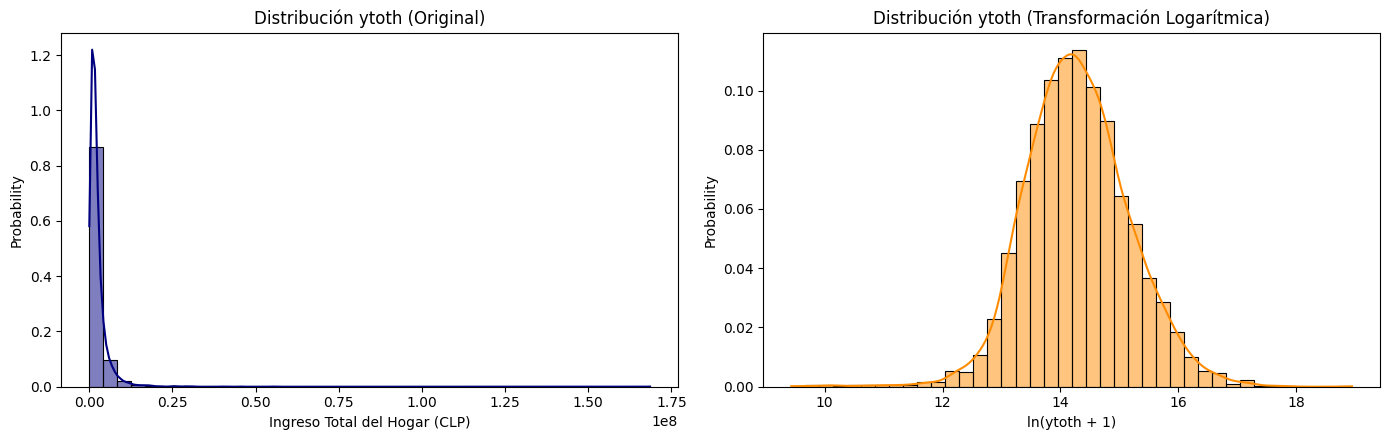

Target Original  -> Media: $2,441,954 | Mediana: $1,539,050 | IQR: $1,853,083
Coef. Asimetría  -> Original: 20.21 | Logarítmico: 0.03


In [79]:
# -------------------------------------------------------------------------
# 3. EDA DE LA VARIABLE OBJETIVO (INGRESOS TOTALES)
# -------------------------------------------------------------------------
# Creación de la versión logarítmica para mitigar asimetría
df["ytoth_log"] = np.log1p(df[TARGET_COL])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Escala original (CLP)
sns.histplot(
    df[TARGET_COL],
    bins=40,
    kde=True,
    color="navy",
    ax=axes[0],
    stat="probability",
)
axes[0].set_title(f"Distribución {TARGET_COL} (Original)")
axes[0].set_xlabel("Ingreso Total del Hogar (CLP)")

# Escala logarítmica ln(y + 1)
sns.histplot(
    df["ytoth_log"],
    bins=40,
    kde=True,
    color="darkorange",
    ax=axes[1],
    stat="probability",
)
axes[1].set_title(f"Distribución {TARGET_COL} (Transformación Logarítmica)")
axes[1].set_xlabel("ln(ytoth + 1)")

plt.tight_layout()
plt.show()

# Estadísticos paramétricos y de forma
q25, q50, q75 = df[TARGET_COL].quantile([0.25, 0.50, 0.75])
print(
    f"Target Original  -> Media: ${df[TARGET_COL].mean():,.0f} | Mediana: ${q50:,.0f} | IQR: ${q75 - q25:,.0f}"
)
print(
    f"Coef. Asimetría  -> Original: {df[TARGET_COL].skew():.2f} | Logarítmico: {df['ytoth_log'].skew():.2f}"
)



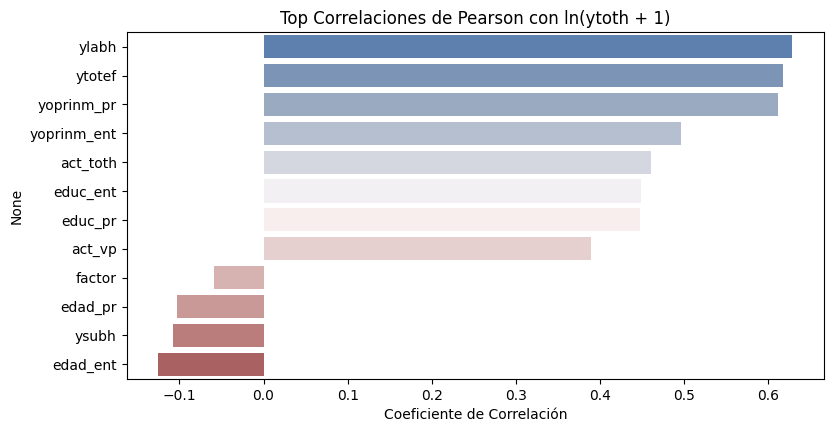

In [16]:
# -------------------------------------------------------------------------
# 4. ANÁLISIS DE CORRELACIONES (COVARIABLES NUMÉRICAS VS TARGET)
# -------------------------------------------------------------------------
if numerical_cols:
    # Correlación lineal contra target logarítmico
    corr_series = (
        df[numerical_cols]
        .apply(lambda col: col.corr(df["ytoth_log"]))
        .sort_values(ascending=False)
    )

    top_corr = pd.concat([corr_series.head(8), corr_series.tail(4)])

    plt.figure(figsize=(9, 4.5))
    sns.barplot(x=top_corr.values, y=top_corr.index, palette="vlag")
    plt.title("Top Correlaciones de Pearson con ln(ytoth + 1)")
    plt.xlabel("Coeficiente de Correlación")
    plt.show()



In [17]:
# -------------------------------------------------------------------------
# 5. ANÁLISIS BIVARIADO: CATEGÓRICAS CLAVE VS INGRESO LOGARÍTMICO
# -------------------------------------------------------------------------
# Seleccionar variables con mayor relevancia conceptual para contrastar con el target
key_factors = [
    c
    for c in [
        "educ_max",
        "tenencia_vivienda",
        "categoria_ocupacional",
        "tiene_cta_cte",
    ]
    if c in categorical_cols
]

if key_factors:
    fig, axes = plt.subplots(
        len(key_factors), 1, figsize=(10, 4.2 * len(key_factors))
    )
    if len(key_factors) == 1:
        axes = [axes]

    for ax, col in zip(axes, key_factors):
        # Ordenar por mediana de ingreso logarítmico descendente
        cat_order = (
            df.groupby(col)["ytoth_log"]
            .median()
            .sort_values(ascending=False)
            .index
        )
        sns.boxplot(
            data=df,
            x=col,
            y="ytoth_log",
            order=cat_order,
            ax=ax,
            palette="Blues_r",
            showmeans=True,
            meanprops={
                "marker": "o",
                "markerfacecolor": "red",
                "markeredgecolor": "black",
            },
        )
        ax.set_title(
            f"ln({TARGET_COL}) según variable: {col} (Punto rojo = Media)"
        )
        ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
        ax.set_ylabel("ln(ytoth + 1)")

    plt.tight_layout()
    plt.show()



In [18]:
# -------------------------------------------------------------------------
# 6. IDENTIFICACIÓN Y CAPPING DE OUTLIERS MULTIVARIADOS/NUMÉRICOS
# -------------------------------------------------------------------------
# Winsorización al percentil 99 en variables numéricas seleccionadas para evitar distorsiones
for col in numerical_cols:
    p99 = df[col].quantile(0.99)
    df[f"{col}_capped"] = np.where(df[col] > p99, p99, df[col])

print("\n--- EDA completado con éxito. Estructura lista para preprocesamiento y modelado ---")


--- EDA completado con éxito. Estructura lista para preprocesamiento y modelado ---


# **Aprendizaje Supervisado**

Dado que la variable objetivo es el ingreso continuo del hogar ($y = \text{ytoth}$ transformado a logaritmo), el problema corresponde estrictamente a una regresión, no a una clasificación. Por definición matemática:Balanceo de clases (SMOTE, submuestreo, etc.): No aplica directamente a variables objetivo continuas (está reservado para targets discretos desbalanceados). En su lugar, el sesgo poblacional y la asimetría se abordan mediante la transformación $\ln(y + 1)$ y la incorporación opcional de los factores de expansión (sample_weight = fac_hog).

**Reducción** de dimensionalidad: Se implementa vía PCA dentro de los pipelines de modelos lineales para mitigar colinealidad y redundancia. En los modelos basados en árboles no es estrictamente necesario, pero se evalúa su impacto.

**Validación** cruzada: Se aplica KFold de 5 particiones (cv=5) encapsulado dentro de cada pipeline para prevenir fuga de información (data leakage).

In [80]:
# -------------------------------------------------------------------------
# 1. PARTICIÓN TRAIN / TEST SPLIT (80% / 20%)
# -------------------------------------------------------------------------
X = df[feature_candidates]
y = df["ytoth_log"]


# Partición 80/20 fijando semilla para reproducibilidad

X_train, X_test,y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)


print(f"Dimensiones Train (80%): {X_train.shape[0]} observaciones")
print(f"Dimensiones Test  (20%): {X_test.shape[0]} observaciones")



Dimensiones Train (80%): 3698 observaciones
Dimensiones Test  (20%): 925 observaciones


In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
# -------------------------------------------------------------------------
# 2. TRANSFORMADORES Y PIPELINE DE PREPROCESAMIENTO
# -------------------------------------------------------------------------
numeric_features = [c for c in X.columns if c in numerical_cols]
categorical_features = [c for c in X.columns if c in categorical_cols]

# 1. Pipeline para variables numéricas: Imputación por mediana + Escalamiento
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer_num",
            SimpleImputer(strategy="median"),
        ),  # Llena NaN con la mediana calculada solo en Train
        ("scaler", StandardScaler()),
    ]
)

# 2. Pipeline para variables categóricas: Imputación con etiqueta constante + One-Hot
categorical_pipeline = Pipeline(
    steps=[
        # Imputa con el código numérico más frecuente (mismo dtype)
        ("imputer_cat", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore", sparse_output=False, drop="first"
            ),
        ),
    ]
)

# 3. Ensamblado en el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

In [85]:
from sklearn.linear_model import Lasso, LinearRegression, Ridge
# -------------------------------------------------------------------------
# 3. DEFINICIÓN DE MODELOS
# -------------------------------------------------------------------------
models = {
    "OLS (Lineal)": Pipeline(
        steps=[("prep", preprocessor), ("reg", LinearRegression())]
    ),
    "Ridge": Pipeline(
        steps=[("prep", preprocessor), ("reg", Ridge(alpha=1.0))]
    ),
    "Lasso": Pipeline(
        steps=[
            ("prep", preprocessor),
            ("reg", Lasso(alpha=0.01, random_state=42)),
        ]
    ),
    "PCA (90% var) + Ridge": Pipeline(
        steps=[
            ("prep", preprocessor),
            ("pca", PCA(n_components=0.90, random_state=42)),
            ("reg", Ridge(alpha=1.0)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("prep", preprocessor),
            (
                "reg",
                RandomForestRegressor(
                    n_estimators=150, max_depth=12, n_jobs=-1, random_state=42
                ),
            ),
        ]
    )

}

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
# -------------------------------------------------------------------------
# 4. VALIDACIÓN CRUZADA EN TRAIN (5-FOLD) Y EVALUACIÓN FINAL EN TEST
# -------------------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "r2": "r2",
    "neg_rmse": "neg_root_mean_squared_error",
    "neg_mae": "neg_mean_absolute_error",
}

results = []

for name, pipe in models.items():
    # A. Cross Validation (solo en Train)
    cv_res = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    cv_r2_mean = np.mean(cv_res["test_r2"])
    cv_rmse_mean = -np.mean(cv_res["test_neg_rmse"])

    # B. Ajuste en Train completo y Evaluación en Test (20% Holdout)
    pipe.fit(X_train, y_train)
    y_pred_log = pipe.predict(X_test)

    # Métricas en escala logarítmica
    test_r2 = r2_score(y_test, y_pred_log, sample_weight=w_test)
    test_rmse = np.sqrt(
        mean_squared_error(y_test, y_pred_log, sample_weight=w_test)
    )
    test_mae = mean_absolute_error(y_test, y_pred_log, sample_weight=w_test)

    # Retransformación a escala monetaria original (Pesos Chilenos)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    test_mae_clp = mean_absolute_error(
        y_test_real, y_pred_real, sample_weight=w_test
    )

    results.append(
        {
            "Modelo": name,
            "CV R² (Train)": cv_r2_mean,
            "CV RMSE (Train)": cv_rmse_mean,
            "Test R²": test_r2,
            "Test RMSE (log)": test_rmse,
            "Test MAE (log)": test_mae,
            "Test MAE (CLP)": test_mae_clp,
        }
    )

In [87]:
# -------------------------------------------------------------------------
# 5. MATRIZ COMPARATIVA FINAL
# -------------------------------------------------------------------------
df_comparison = (
    pd.DataFrame(results)
    .sort_values(by="Test R²", ascending=False)
    .reset_index(drop=True)
)


print("\n" + "=" * 95)
print(
    "            MATRIZ COMPARATIVA: DESEMPEÑO CV EN TRAIN VS EVALUACIÓN EN TEST (20%)"
)
print("=" * 95)
print(df_comparison)


            MATRIZ COMPARATIVA: DESEMPEÑO CV EN TRAIN VS EVALUACIÓN EN TEST (20%)
                  Modelo  CV R² (Train)  CV RMSE (Train)   Test R²  \
0          Random Forest       0.994894         0.061841  0.993833   
1                  Ridge       0.648222         0.497394  0.783278   
2           OLS (Lineal)       0.657792         0.492296  0.782199   
3                  Lasso       0.566682         0.537781  0.766002   
4  PCA (90% var) + Ridge       0.591028         0.540607  0.726555   

   Test RMSE (log)  Test MAE (log)  Test MAE (CLP)  
0         0.070684        0.015741    61253.310048  
1         0.419016        0.293574   753794.345162  
2         0.420057        0.293880   761941.417926  
3         0.435396        0.303961   789075.788429  
4         0.470667        0.330459   969011.201228  


# **Aprendizaje no Supervisado**
Balanceo de clases: No existe ni aplica en modelos no supervisados, ya que no hay clases predefinidas ni variables objetivo a equilibrar.

Reducción de dimensionalidad: Es indispensable. Tras aplicar One-Hot Encoding, la matriz se vuelve de alta dimensión y rala (curse of dimensionality), lo cual distorsiona las distancias euclidianas. Reducir con PCA o TruncatedSVD estabiliza métricas geométricas como distancias inter-cluster.

Validación cruzada: Los algoritmos de agrupamiento no optimizan una función de pérdida con particiones clásicas de Train/Test. Para evaluar estabilidad y generalización sin supervisión, se implementa una validación cruzada de estabilidad (Subsampling CV), midiendo métricas intrínsecas en múltiples submuestras aleatorias:Silhouette Score $[-1, 1]$: Cohesión interna frente a separación (más alto es mejor).Calinski-Harabasz Index $[0, \infty)$: Razón entre dispersión inter-cluster e intra-cluster (más alto es mejor).Davies-Bouldin Index $[0, \infty)$: Similitud promedio entre clusters (más bajo es mejor, $0$ es óptimo).

In [88]:
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans, MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# -------------------------------------------------------------------------
# 1. PREPROCESAMIENTO DIRECTO (SIN TARGET)
# -------------------------------------------------------------------------
numeric_features = [c for c in X.columns if c in numerical_cols]
categorical_features = [c for c in X.columns if c in categorical_cols]

num_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore", sparse_output=False, drop="first"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_features),
        ("cat", cat_pipe, categorical_features),
    ]
)

# -------------------------------------------------------------------------
# 2. REDUCCIÓN DE DIMENSIONALIDAD SIMPLE (2 COMPONENTES)
# -------------------------------------------------------------------------
X_dense = preprocessor.fit_transform(X)

# Proyección directa a 2D para máxima simplicidad e interpretabilidad
pca = PCA(n_components=2, random_state=42)
X_pca2 = pca.fit_transform(X_dense)

# -------------------------------------------------------------------------
# 3. DEFINICIÓN DE MODELOS SIMPLES (K = 3 PERFILES DE HOGAR)
# -------------------------------------------------------------------------
K = 3

models = {
    "K-Means": KMeans(n_clusters=K, n_init=10, random_state=42),
    "MiniBatch K-Means": MiniBatchKMeans(
        n_clusters=K, batch_size=256, random_state=42
    ),
    "Aglomerativo (Jerárquico)": AgglomerativeClustering(n_clusters=K),
}

# -------------------------------------------------------------------------
# 4. EVALUACIÓN Y MATRIZ DE COMPORTAMIENTO (5 SPLITS DE ESTABILIDAD)
# -------------------------------------------------------------------------
rng = np.random.RandomState(42)
records = []

for name, model in models.items():
    sil_list = []
    ch_list = []
    db_list = []

    # 5 corridas sobre submuestras del 80% para evaluar estabilidad
    for _ in range(5):
        sample_idx = rng.choice(
            len(X_pca2), size=int(0.80 * len(X_pca2)), replace=False
        )
        X_sub = X_pca2[sample_idx]

        # Ajuste y asignación de etiquetas
        labels = model.fit_predict(X_sub)

        # Métricas geométricas estándar
        sil_list.append(
            silhouette_score(
                X_sub,
                labels,
                sample_size=min(1500, len(X_sub)),
                random_state=42,
            )
        )
        ch_list.append(calinski_harabasz_score(X_sub, labels))
        db_list.append(davies_bouldin_score(X_sub, labels))

    records.append(
        {
            "Modelo": name,
            "Silhouette (↑)": np.mean(sil_list),
            "Calinski-Harabasz (↑)": np.mean(ch_list),
            "Davies-Bouldin (↓)": np.mean(db_list),
        }
    )

# -------------------------------------------------------------------------
# 5. MATRIZ COMPARATIVA FINAL
# -------------------------------------------------------------------------
df_metrics = (
    pd.DataFrame(records)
    .sort_values(by="Silhouette (↑)", ascending=False)
    .reset_index(drop=True)
)


print("=" * 70)
print(f"      COMPARATIVA DE MODELOS NO SUPERVISADOS SIMPLES (k={K})")
print("=" * 70)
print(df_metrics)

      COMPARATIVA DE MODELOS NO SUPERVISADOS SIMPLES (k=3)
                      Modelo  Silhouette (↑)  Calinski-Harabasz (↑)  \
0  Aglomerativo (Jerárquico)        0.609443            1960.032006   
1                    K-Means        0.589253            2187.131884   
2          MiniBatch K-Means        0.556986            2050.325885   

   Davies-Bouldin (↓)  
0            0.944577  
1            0.987199  
2            1.002650  


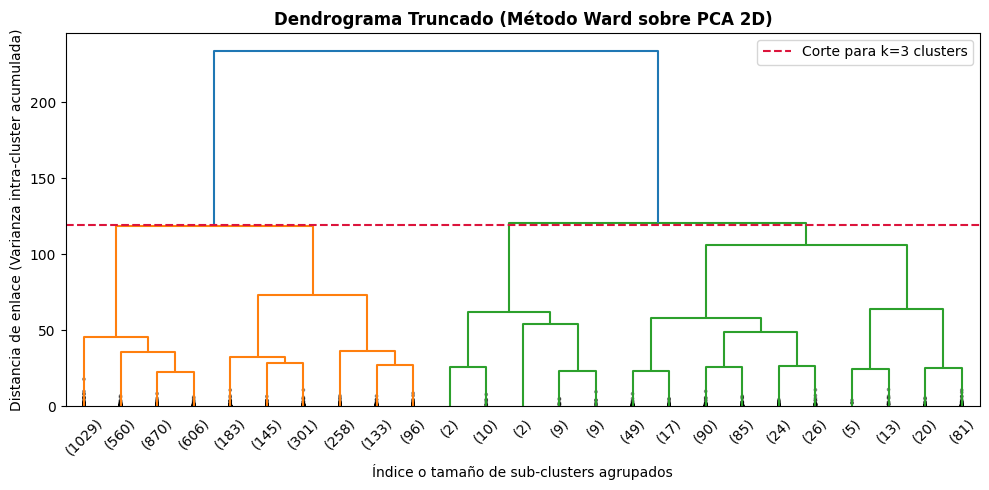

In [91]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Calcular matriz de enlace jerárquico usando el método de Ward
linked = linkage(X_pca2, method="ward")

plt.figure(figsize=(10, 5))

# Truncar el árbol mostrando solo las últimas 25 fusiones
dendrogram(
    linked,
    truncate_mode="lastp",
    p=25,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True,
)

# Línea horizontal que ilustra el corte para k = 3
# El umbral de distancia se toma entre la 2da y 3ra fusión más alta
dist_corte = (linked[-2, 2] + linked[-3, 2]) / 2
plt.axhline(
    y=dist_corte,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"Corte para k={K} clusters",
)

plt.title(
    "Dendrograma Truncado (Método Ward sobre PCA 2D)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Índice o tamaño de sub-clusters agrupados")
plt.ylabel("Distancia de enlace (Varianza intra-cluster acumulada)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

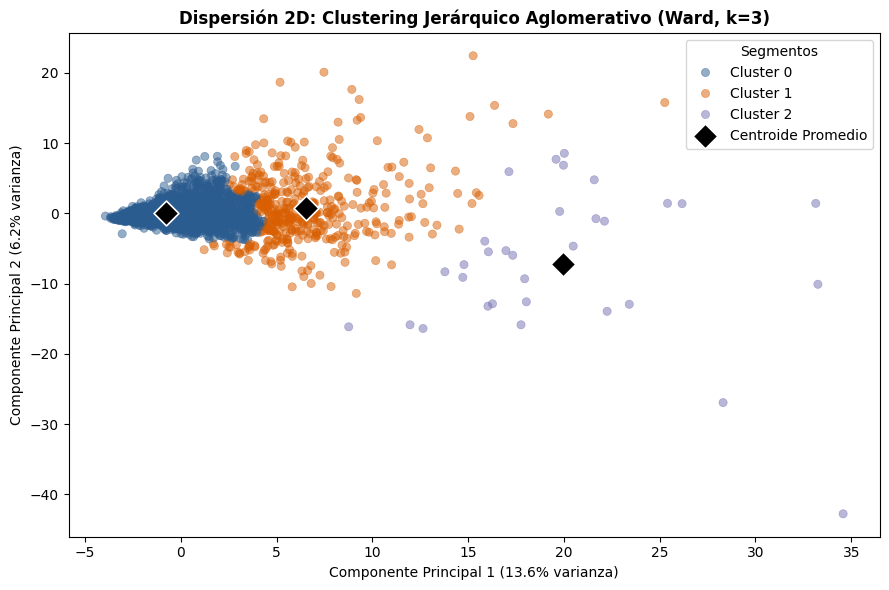

In [92]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering

# 1. Ajuste del modelo jerárquico sobre el espacio PCA de 2 dimensiones
K = 3
agg_model = AgglomerativeClustering(n_clusters=K, linkage="ward")
agg_labels = agg_model.fit_predict(X_pca2)

# 2. DataFrame para visualización
df_agg_plot = pd.DataFrame(
    {
        "PCA1": X_pca2[:, 0],
        "PCA2": X_pca2[:, 1],
        "Cluster": [f"Cluster {c}" for c in agg_labels],
    }
)

# 3. Calcular centroides empíricos para referencia visual
centroids_agg = (
    df_agg_plot.groupby("Cluster")[["PCA1", "PCA2"]].mean().values
)

# 4. Gráfico de dispersión
plt.figure(figsize=(9, 6))
palette = ["#2b5c8f", "#d95f02", "#7570b3"]

sns.scatterplot(
    data=df_agg_plot,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette=palette,
    alpha=0.5,
    s=35,
    edgecolor=None,
)

# Marcadores de centroides promedio
plt.scatter(
    centroids_agg[:, 0],
    centroids_agg[:, 1],
    c="black",
    s=160,
    marker="D",
    edgecolors="white",
    linewidths=1.2,
    label="Centroide Promedio",
    zorder=10,
)

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.title(
    f"Dispersión 2D: Clustering Jerárquico Aglomerativo (Ward, k={K})",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel(f"Componente Principal 1 ({var_pc1:.1f}% varianza)")
plt.ylabel(f"Componente Principal 2 ({var_pc2:.1f}% varianza)")
plt.legend(title="Segmentos", loc="best", frameon=True)
plt.tight_layout()
plt.show()

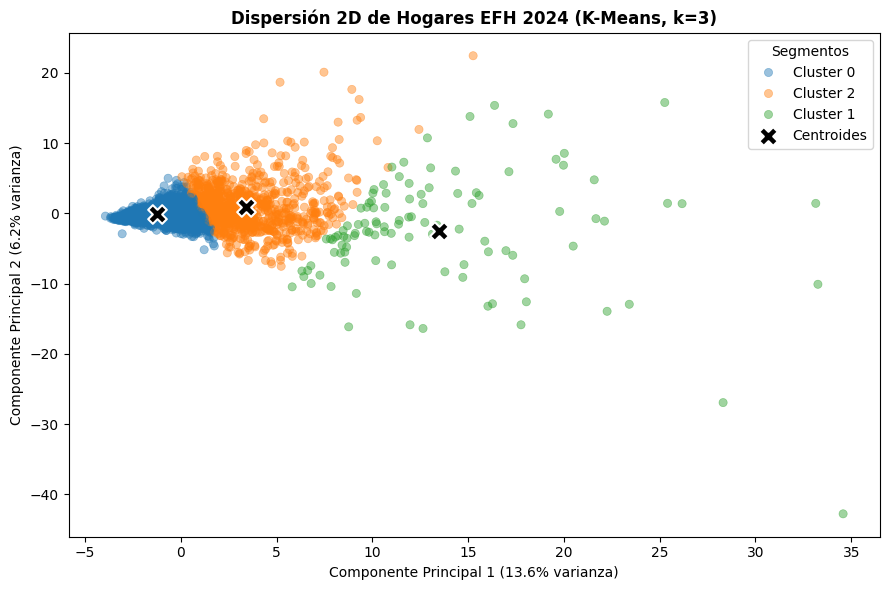

In [89]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

# -------------------------------------------------------------------------
# 1. AJUSTE DE K-MEANS SOBRE EL ESPACIO PCA (2 COMPONENTES)
# -------------------------------------------------------------------------
# X_pca2 corresponde a la matriz de 2 dimensiones generada en el paso previo
K = 3
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca2)
centroids = kmeans.cluster_centers_

# DataFrame auxiliar para graficar
df_plot = pd.DataFrame(
    {
        "PCA1": X_pca2[:, 0],
        "PCA2": X_pca2[:, 1],
        "Cluster": [f"Cluster {c}" for c in cluster_labels],
    }
)

# -------------------------------------------------------------------------
# 2. VISUALIZACIÓN DE CLUSTERS Y CENTROIDES
# -------------------------------------------------------------------------
plt.figure(figsize=(9, 6))
palette = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Gráfico de dispersión de las observaciones
sns.scatterplot(
    data=df_plot,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette=palette,
    alpha=0.45,
    s=35,
    edgecolor=None,
)

# Posicionamiento de los centroides de cada cluster
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="black",
    s=180,
    marker="X",
    linewidths=1.5,
    edgecolors="white",
    label="Centroides",
    zorder=10,
)

# Varianza explicada por cada componente principal (obtenida del objeto pca previo)
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.title(
    f"Dispersión 2D de Hogares EFH 2024 (K-Means, k={K})",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel(f"Componente Principal 1 ({var_pc1:.1f}% varianza)")
plt.ylabel(f"Componente Principal 2 ({var_pc2:.1f}% varianza)")
plt.legend(title="Segmentos", loc="best", frameon=True)
plt.tight_layout()
plt.show()